# Тема 3. Деревья решений и метод ближайших соседей

## Занятие 3 (теория)

**На занятии 1 мы вручную собрали правило** «международный тариф + больше 3 обращений в поддержку → отток» с точностью 85.8%. По сути это было двухуровневое дерево решений — просто мы построили его руками, перебирая признаки на глаз. **Сегодня научим компьютер строить такие правила самому** — по всем признакам сразу, а не по двум выбранным вручную — и получим первую настоящую модель машинного обучения.

**План занятия:** как дерево решений выбирает, о чём спросить → переобучение и глубина дерева → дерево на данных оттока: бьём ли мы 85.8%? → метод ближайших соседей (kNN) → отложенная выборка и кросс-валидация → плюсы/минусы.

**Практика** — в `lesson03_trees_knn_practice.ipynb` (Titanic — первая настоящая модель на этом датасете).
**Дополнительно** (распознавание цифр, проклятие размерности, дерево для регрессии) — в `lesson03_trees_knn_advanced.ipynb`.

**Обозначения:** как и раньше — ячейки `# ...` пишутся вживую на занятии.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

sns.set()
%config InlineBackend.figure_format = 'svg'
RANDOM_STATE = 42

---
## 1. Как дерево решений выбирает, о чём спросить

Дерево решений — это последовательность вопросов вида «признак X больше порога t?», в конце каждой ветки — предсказание класса. Ровно то же самое мы делали руками в теме 1:

```
International plan == Yes?
├── Да → Customer service calls > 3?
│         ├── Да  → Churn = 1
│         └── Нет → Churn = 0
└── Нет → Churn = 0
```

Вопрос в том, **как выбрать, по какому признаку и с каким порогом расщеплять** узел, чтобы дерево строилось не «на глаз», как у нас, а автоматически.

**Идея:** после хорошего расщепления каждая из двух групп должна быть более «однородной» по классам, чем была до него. Меру неоднородности называют **энтропией**: у группы из одного класса энтропия = 0, у группы 50/50 — максимальна.

Пример: в узле 20 шариков, 9 синих и 11 жёлтых.

In [2]:
def entropy(p_blue):
    p_yellow = 1 - p_blue
    if p_blue in (0, 1):
        return 0.0
    return -(p_blue * np.log2(p_blue) + p_yellow * np.log2(p_yellow))

print("Энтропия узла (9 синих, 11 жёлтых):", round(entropy(9 / 20), 3))
print("Энтропия после идеального расщепления (все синие отдельно):", entropy(1.0), "и", entropy(0.0))

Энтропия узла (9 синих, 11 жёлтых): 0.993
Энтропия после идеального расщепления (все синие отдельно): 0.0 и 0.0


Алгоритм на каждом шаге перебирает признаки и пороги и выбирает то расщепление, которое **сильнее всего снижает энтропию** (либо аналог — критерий Джини, он же по умолчанию в sklearn — считается похоже, но чуть быстрее). Дальше рекурсивно повторяет то же самое для каждой из двух получившихся групп.

---
## 2. Переобучение: глубина решает всё

Посмотрим на игрушечном 2D-примере, как выглядит граница, которую строит дерево, и как она меняется с глубиной.

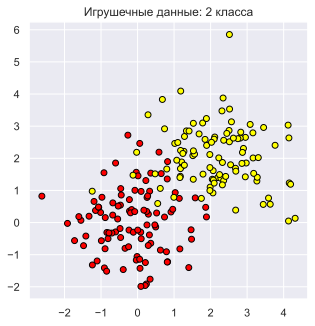

In [3]:
np.random.seed(RANDOM_STATE)
train_data = np.random.normal(size=(100, 2))
train_labels = np.zeros(100)
train_data = np.r_[train_data, np.random.normal(size=(100, 2), loc=2)]
train_labels = np.r_[train_labels, np.ones(100)]

plt.figure(figsize=(5, 5))
plt.scatter(train_data[:, 0], train_data[:, 1], c=train_labels, cmap="autumn", edgecolors="black")
plt.title("Игрушечные данные: 2 класса");

**Прежде чем смотреть — угадайте:** если дать дереву решений неограниченную глубину, точность на этих же точках, на которых оно обучалось, будет 100% или меньше? А если ограничить глубину одним вопросом?

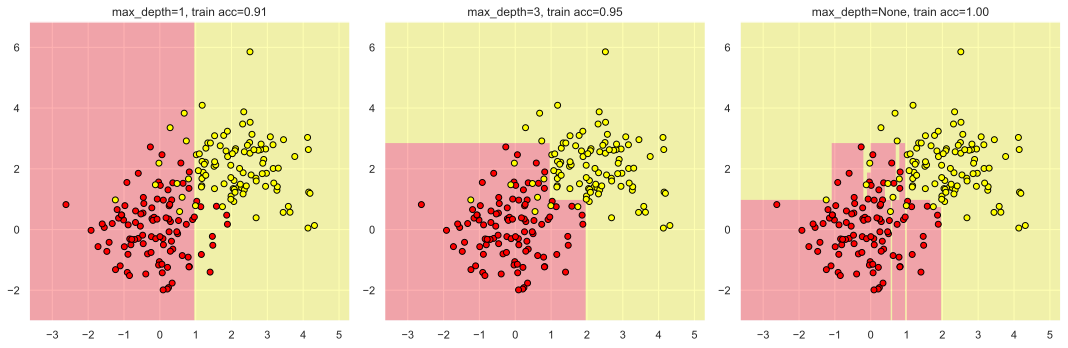

In [4]:
def get_grid(data, eps=0.05):
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    return np.meshgrid(np.arange(x_min, x_max, eps), np.arange(y_min, y_max, eps))

_, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, depth in zip(axes, [1, 3, None]):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    clf.fit(train_data, train_labels)
    xx, yy = get_grid(train_data)
    predicted = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.pcolormesh(xx, yy, predicted, cmap="autumn", alpha=0.3, shading="auto", rasterized=True)
    ax.scatter(train_data[:, 0], train_data[:, 1], c=train_labels, cmap="autumn", edgecolors="black")
    ax.set_title(f"max_depth={depth}, train acc={clf.score(train_data, train_labels):.2f}")
plt.tight_layout();

При `max_depth=1` — одна прямая, простая граница, часть точек ошибочно классифицирована. При `max_depth=3` — граница уже неплохо разделяет классы. При неограниченной глубине — дерево **подгоняется под каждую отдельную точку**, включая шум, и рисует изрезанную границу, которая идеально проходит через обучающие данные, но вряд ли обобщится на новые. Это и есть **переобучение**.

**Ключевые параметры, которые с этим борются:**
- `max_depth` — максимальная глубина дерева
- `min_samples_leaf` — минимум наблюдений в листе (не давать дереву создавать лист ради одной точки)
- `min_samples_split` — минимум наблюдений в узле, чтобы его можно было расщеплять
- `criterion` — `gini` (по умолчанию) или `entropy`

---
## 3. Дерево решений на данных оттока: бьём ли 85.8%?

Вернёмся к датасету телекома. Закодируем `International plan`/`Voice mail plan` в 0/1 (дерево работает с числами) и разделим данные на обучающую и отложенную (валидационную) части — модель нельзя проверять на тех же данных, на которых она обучалась, это ключевое правило, к которому вернёмся в разделе про кросс-валидацию.

In [6]:
df = pd.read_csv("../../data/telecom_churn.csv")
df["Churn"] = df["Churn"].astype(int)
df["International plan"] = (df["International plan"] == "Yes").astype(int)
df["Voice mail plan"] = (df["Voice mail plan"] == "Yes").astype(int)

X = df.drop(columns=["State", "Churn"])
y = df["Churn"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_valid.shape

((2333, 18), (1000, 18))

**Задание преподавателю на занятии:** обучите `DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)` на `X_train`/`y_train` и посчитайте `.score()` на `X_valid`/`y_valid`. Побили 85.8%?

In [7]:
# tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
# tree.fit(...)
# tree.score(...)


Дерево даёт около **93-94%** — заметно больше нашего ручного правила. Посмотрим, какие признаки дерево посчитало важными (`feature_importances_`) — и сверим с тем, что мы увидели глазами на прошлом занятии в box plot по классам:

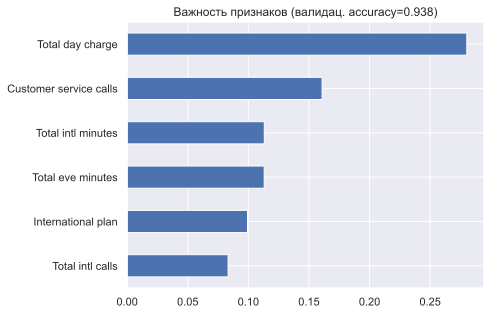

In [8]:
tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

importances = pd.Series(tree.feature_importances_, index=X.columns).sort_values()
importances.tail(6).plot(kind="barh", title=f"Важность признаков (валидац. accuracy={tree.score(X_valid, y_valid):.3f})");

`Total day charge`, `Customer service calls`, `International plan` — та же тройка (плюс близкие к ним `Total intl`/`Total eve minutes`), что мы визуально выделили на занятии 2 через box plot по классам. Приятно, когда глаз и алгоритм сходятся.

Посмотрим на само дерево (возьмём неглубокое — глубокое нечитаемо):

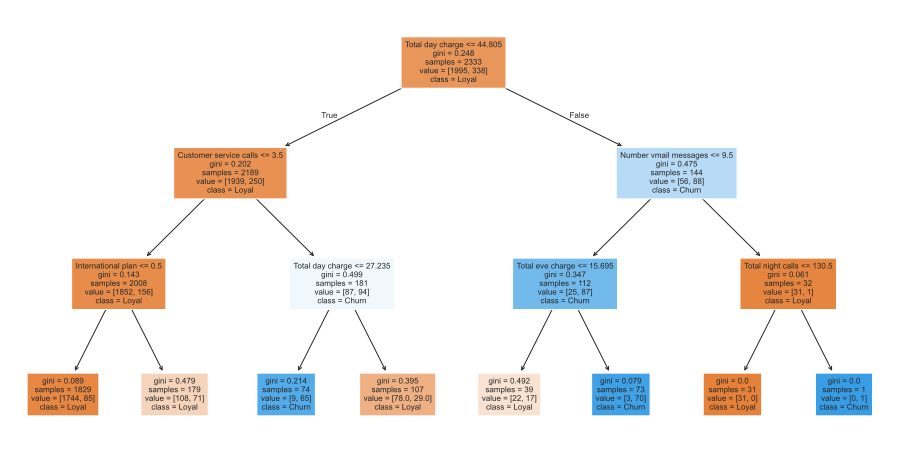

In [9]:
small_tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
small_tree.fit(X_train, y_train)

plt.figure(figsize=(16, 8))
plot_tree(small_tree, feature_names=X.columns, class_names=["Loyal", "Churn"], filled=True, fontsize=8)
plt.show()

Первый вопрос, который задаёт дерево — почти наверняка про `Total day charge` или `Customer service calls`, а не про то, что мы выбрали руками. Дерево нашло разбиение лучше нашего.

---
## 4. Метод ближайших соседей (kNN)

Совсем другой принцип: чтобы классифицировать новую точку, находим `k` ближайших к ней точек в обучающей выборке (по евклидову расстоянию) и голосуем большинством их классов. Никакого «обучения» в привычном смысле — вся работа происходит в момент предсказания.

**Важно:** расстояние чувствительно к масштабу признаков — `Total day minutes` (десятки-сотни) и `International plan` (0/1) иначе будут вкладываться в расстояние непропорционально. Перед kNN признаки почти всегда масштабируют.

**Ключевые параметры:** `n_neighbors` (k) — больше k, глаже граница, меньше риск переобучиться, но и меньше нюансов; `metric` — как считать расстояние (по умолчанию евклидово); `weights` — учитывать ли более близких соседей сильнее.

**Задание преподавателю на занятии:** масштабируйте `X_train`/`X_valid` через `StandardScaler`, обучите `KNeighborsClassifier(n_neighbors=10)`, сравните `.score()` с деревом.

In [ ]:
# scaler = StandardScaler()
# X_train_s = scaler.fit_transform(X_train)
# X_valid_s = scaler.transform(X_valid)
# knn = KNeighborsClassifier(n_neighbors=10)
# knn.fit(X_train_s, y_train)
# knn.score(X_valid_s, y_valid)


kNN здесь даёт около **87-89%** — хуже дерева. Урок не в том, что kNN «слабее», а в том, что **разные алгоритмы подходят разным данным** — на других задачах (увидим на цифрах MNIST в `lesson03_trees_knn_advanced.ipynb`) соотношение будет обратным.

---
## 5. Отложенная выборка и кросс-валидация

Одно разбиение `train_test_split` — это одна случайная выборка 30% данных. Могло повезти или не повезти. **Кросс-валидация (CV)** — разбить данные на `k` частей (*фолдов*), по очереди использовать каждую как валидационную, а на остальных обучаться, и усреднить `k` полученных оценок качества. Даёт более честную и устойчивую оценку.

In [8]:
cv_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE), X, y, cv=5
)
print("Оценки по 5 фолдам:", cv_scores.round(3))
print("Среднее:", round(cv_scores.mean(), 3))

Оценки по 5 фолдам: [0.933 0.931 0.934 0.938 0.934]
Среднее: 0.934


Оценки по фолдам близки друг к другу — значит, наш единственный `train_test_split` не был случайной удачей, модель стабильно даёт ~93%.

---
## 6. Плюсы и минусы

| | Дерево решений | kNN |
|---|---|---|
| **Плюсы** | Интерпретируемо (можно нарисовать и объяснить), не требует масштабирования, работает с нелинейными зависимостями | Простая идея, ничего не «обучается» заранее, хорошо ловит локальные закономерности |
| **Минусы** | Легко переобучается без ограничений на глубину, неустойчиво к небольшим изменениям в данных (другое дерево при чуть других данных) | Медленно на больших данных (считает расстояния до всех точек), чувствительно к масштабу и «проклятию размерности» (см. advanced) |

---
## Итог занятия

Сегодня разобрали:

- Как дерево решений выбирает расщепления (энтропия/Джини) — и что это ровно та же логика, что мы применяли руками в теме 1
- Переобучение и `max_depth`/`min_samples_leaf`/`min_samples_split`
- Обучили первую настоящую модель на данных оттока — 93%+ против ручных 85.8%
- kNN: идея, масштабирование признаков, ключевые параметры
- `train_test_split` и `cross_val_score` — как честно оценивать качество модели

**Дальше:**
- Практика — `lesson03_trees_knn_practice.ipynb` (первая модель на Titanic)
- Доп. материалы — `lesson03_trees_knn_advanced.ipynb`
- Следующее занятие — линейные модели: другой взгляд на ту же задачу классификации